# ISMN Skill Batch Figures (Cache-Only)

This notebook assumes raw cache files already exist (for example: `*_raw_timeseries.nc`) and **does not read ISMN archives or model daily files**.

For each cache file, it:

1. Loads obs/model timeseries and station mappings from NetCDF.
2. Recomputes per-site skill stats (surface + root-zone) for configured windows.
3. Applies the same observation-day threshold filtering.
4. Builds OL vs DA bar charts (`R`, `anomR`, `ubRMSE`) in the same style as the current notebook.


In [1]:
from pathlib import Path
import os

# Runtime guard for environments where Intel OpenMP SHM setup fails.
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import re
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
import xarray as xr

plt.ioff()
print("Matplotlib backend:", matplotlib.get_backend())
print("MKL_THREADING_LAYER:", os.environ.get("MKL_THREADING_LAYER"))


Matplotlib backend: module://matplotlib_inline.backend_inline
MKL_THREADING_LAYER: SEQUENTIAL


In [2]:
# -------------------------
# User configuration
# -------------------------

CACHE_DIR = Path("./outputs_ismn_network_skill")
CACHE_GLOB = "*_raw_timeseries.nc"
OUTPUT_FIG_DIR = CACHE_DIR / "batch_figures"
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Optionally limit processing to a subset of filenames.
# Leave empty [] to process all files matching CACHE_GLOB.
ONLY_FILES = []

# Validation controls (match current notebook defaults)
MIN_OBS_DAYS_PER_WINDOW = 1000
NMIN = 1000
NMIN_DAY = 30
ADD_ANOMR = True

# Window defaults used by filename modes.
DEFAULT_TWO_PERIOD_PRE_SMAP_START = "2007-06-01"
DEFAULT_TWO_PERIOD_PRE_SMAP_END = "2015-03-31"
DEFAULT_TWO_PERIOD_SMAP_START = "2015-04-01"

DEFAULT_CUSTOM_PRE_ASCAT_END = "2007-05-31"
DEFAULT_CUSTOM_PRE_SMAP_START = "2007-06-01"
DEFAULT_CUSTOM_PRE_SMAP_END = "2015-03-31"
DEFAULT_CUSTOM_SMAP_START = "2015-04-01"

print("CACHE_DIR:", CACHE_DIR.resolve())
print("OUTPUT_FIG_DIR:", OUTPUT_FIG_DIR.resolve())


CACHE_DIR: /Users/amfox/Desktop/geosldas-analysis/outputs_ismn_network_skill
OUTPUT_FIG_DIR: /Users/amfox/Desktop/geosldas-analysis/outputs_ismn_network_skill/batch_figures


In [3]:
# -------------------------
# Repo-local imports
# -------------------------

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break

sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))
from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore

print("REPO_ROOT=", REPO_ROOT)


REPO_ROOT= /Users/amfox/Desktop/geosldas-analysis


In [4]:
# -------------------------
# Cache parsing + loading
# -------------------------

_CACHE_RE = re.compile(
    r"^(?P<network>.+?)_(?P<window_mode>two_period|custom|full_period)_(?P<start>\d{8})_(?P<end>\d{8})_(?P<rz_tag>.+)_raw_timeseries\.nc$"
)


def parse_cache_filename(path: Path):
    m = _CACHE_RE.match(path.name)
    if m is None:
        raise ValueError(f"Unrecognized cache filename pattern: {path.name}")

    start = pd.Timestamp(datetime.strptime(m.group("start"), "%Y%m%d")).normalize()
    end = pd.Timestamp(datetime.strptime(m.group("end"), "%Y%m%d")).normalize()
    if end < start:
        raise ValueError(f"Cache date span invalid: {path.name}")

    return {
        "network": m.group("network"),
        "window_mode": m.group("window_mode"),
        "start": start,
        "end": end,
        "rz_tag": m.group("rz_tag"),
    }


def _clip_window(name, start, end, cache_start, cache_end):
    t0 = max(pd.Timestamp(start).normalize(), cache_start)
    t1 = min(pd.Timestamp(end).normalize(), cache_end)
    if t1 < t0:
        return None
    # Inclusive end-day behavior
    t1 = t1 + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    return (name, t0, t1)


def build_window_bounds(window_mode: str, cache_start: pd.Timestamp, cache_end: pd.Timestamp):
    window_mode = str(window_mode)

    if window_mode == "two_period":
        candidates = [
            ("pre-SMAP", DEFAULT_TWO_PERIOD_PRE_SMAP_START, DEFAULT_TWO_PERIOD_PRE_SMAP_END),
            ("SMAP-era", DEFAULT_TWO_PERIOD_SMAP_START, cache_end.strftime("%Y-%m-%d")),
        ]
    elif window_mode == "custom":
        candidates = [
            ("pre-ASCAT", cache_start.strftime("%Y-%m-%d"), DEFAULT_CUSTOM_PRE_ASCAT_END),
            ("pre-SMAP", DEFAULT_CUSTOM_PRE_SMAP_START, DEFAULT_CUSTOM_PRE_SMAP_END),
            ("SMAP-era", DEFAULT_CUSTOM_SMAP_START, cache_end.strftime("%Y-%m-%d")),
        ]
    elif window_mode == "full_period":
        candidates = [("full-period", cache_start.strftime("%Y-%m-%d"), cache_end.strftime("%Y-%m-%d"))]
    else:
        raise ValueError(f"Unsupported window_mode: {window_mode}")

    bounds = []
    for name, s, e in candidates:
        w = _clip_window(name, s, e, cache_start, cache_end)
        if w is not None:
            bounds.append(w)

    if len(bounds) == 0:
        raise RuntimeError(f"No valid windows after clipping for mode={window_mode} span={cache_start.date()}..{cache_end.date()}")

    return bounds


def load_raw_timeseries_cache(cache_path: Path):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        raise FileNotFoundError(f"Raw timeseries cache not found: {cache_path}")

    with xr.open_dataset(cache_path) as ds:
        time_index = pd.DatetimeIndex(ds["time"].values)
        stations = [str(s) for s in ds["station"].values]

        obs_surface_arr = np.asarray(ds["obs_surface"].values, dtype=float)
        obs_rz_arr = np.asarray(ds["obs_rz"].values, dtype=float)

        station_lat = np.asarray(ds["station_lat"].values, dtype=float) if "station_lat" in ds else np.full(len(stations), np.nan)
        station_lon = np.asarray(ds["station_lon"].values, dtype=float) if "station_lon" in ds else np.full(len(stations), np.nan)

        obs_surface_daily_by_station = {}
        obs_rz_daily_by_station = {}
        for i, stn in enumerate(stations):
            obs_surface_daily_by_station[stn] = pd.Series(obs_surface_arr[:, i], index=time_index).dropna()
            obs_rz_daily_by_station[stn] = pd.Series(obs_rz_arr[:, i], index=time_index).dropna()

        exp_keys = []
        for v in ds.data_vars:
            if str(v).startswith("model_surface_"):
                exp_key = str(v)[len("model_surface_"):]
                if f"model_rz_{exp_key}" in ds:
                    exp_keys.append(exp_key)
        exp_keys = sorted(set(exp_keys))
        if len(exp_keys) == 0:
            raise RuntimeError(f"No model_surface/model_rz experiment variables in {cache_path}")

        model_surface_by_exp = {}
        model_rz_by_exp = {}
        model_site_maps = {}

        for exp_key in exp_keys:
            model_surface_by_exp[exp_key] = pd.DataFrame(
                np.asarray(ds[f"model_surface_{exp_key}"].values, dtype=float),
                index=time_index,
                columns=stations,
            )
            model_rz_by_exp[exp_key] = pd.DataFrame(
                np.asarray(ds[f"model_rz_{exp_key}"].values, dtype=float),
                index=time_index,
                columns=stations,
            )

            idx_v = f"tile_index_{exp_key}"
            lat_v = f"tile_lat_{exp_key}"
            lon_v = f"tile_lon_{exp_key}"
            d_v = f"tile_distance_km_{exp_key}"

            rows = []
            if idx_v in ds:
                tile_idx = np.asarray(ds[idx_v].values, dtype=int)
                tile_lat = np.asarray(ds[lat_v].values, dtype=float) if lat_v in ds else np.full(len(stations), np.nan)
                tile_lon = np.asarray(ds[lon_v].values, dtype=float) if lon_v in ds else np.full(len(stations), np.nan)
                tile_dist = np.asarray(ds[d_v].values, dtype=float) if d_v in ds else np.full(len(stations), np.nan)

                for i, stn in enumerate(stations):
                    if tile_idx[i] < 0:
                        continue
                    rows.append(
                        {
                            "station": stn,
                            "station_lat": float(station_lat[i]),
                            "station_lon": float(station_lon[i]),
                            "tile_index": int(tile_idx[i]),
                            "tile_lat": float(tile_lat[i]),
                            "tile_lon": float(tile_lon[i]),
                            "distance_km": float(tile_dist[i]),
                            "distance_metric": np.nan,
                            "distance_method": "from_cache",
                        }
                    )

            model_site_maps[exp_key] = pd.DataFrame(rows)

    station_df = pd.DataFrame({"station": stations, "lat": station_lat, "lon": station_lon})

    return {
        "time_index": time_index,
        "stations": stations,
        "station_df": station_df,
        "obs_surface_daily_by_station": obs_surface_daily_by_station,
        "obs_rz_daily_by_station": obs_rz_daily_by_station,
        "model_surface_by_exp": model_surface_by_exp,
        "model_rz_by_exp": model_rz_by_exp,
        "model_site_maps": model_site_maps,
        "exp_keys": exp_keys,
    }


def build_obs_site_ok_df_from_obs(station_df, obs_surface_daily_by_station, obs_rz_daily_by_station, window_bounds):
    recs = []
    lat_map = station_df.set_index("station")["lat"].to_dict()
    lon_map = station_df.set_index("station")["lon"].to_dict()

    for stn in station_df["station"].astype(str).tolist():
        s_surface = obs_surface_daily_by_station.get(stn, pd.Series(dtype=float))
        s_rz = obs_rz_daily_by_station.get(stn, pd.Series(dtype=float))

        rec = {
            "station": stn,
            "lat": float(lat_map.get(stn, np.nan)),
            "lon": float(lon_map.get(stn, np.nan)),
            "ok": True,
            "error": "",
        }

        for wn, t0, t1 in window_bounds:
            s_sub = s_surface[(s_surface.index >= t0) & (s_surface.index <= t1)]
            r_sub = s_rz[(s_rz.index >= t0) & (s_rz.index <= t1)]
            rec[f"surface_obs_days_{wn}"] = int(np.isfinite(s_sub.to_numpy(dtype=float)).sum())
            rec[f"rz_obs_days_{wn}"] = int(np.isfinite(r_sub.to_numpy(dtype=float)).sum())

        recs.append(rec)

    return pd.DataFrame(recs)


In [5]:
# -------------------------
# Stats helpers
# -------------------------

def calc_full_skill_stats(
    obs_series,
    mod_series,
    nmin=1000,
    nmin_day=30,
    add_anom=True,
    obs_anom_series=None,
    mod_anom_series=None,
):
    pair = pd.concat([obs_series.rename("obs"), mod_series.rename("mod")], axis=1, join="inner").dropna()

    out = {
        "N_pairs": int(len(pair)),
        "R": np.nan,
        "RLO": np.nan,
        "RUP": np.nan,
        "bias": np.nan,
        "CI_bias": np.nan,
        "MSE": np.nan,
        "CI_MSE": np.nan,
        "RMSE": np.nan,
        "RMSELO": np.nan,
        "RMSEUP": np.nan,
        "ubMSE": np.nan,
        "ubMSELO": np.nan,
        "ubMSEUP": np.nan,
        "ubRMSE": np.nan,
        "ubRMSELO": np.nan,
        "ubRMSEUP": np.nan,
        "anomN_pairs": 0,
        "anomR": np.nan,
        "anomRLO": np.nan,
        "anomRUP": np.nan,
    }

    if len(pair) <= int(nmin):
        return out

    arr = np.column_stack([pair["obs"].to_numpy(dtype=float), pair["mod"].to_numpy(dtype=float)])
    st = get_validation_stats(arr, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=int(nmin))

    out["R"] = st["R"]
    out["RLO"] = st["RLO"]
    out["RUP"] = st["RUP"]
    out["bias"] = st["bias"]
    out["CI_bias"] = st["CI_bias"]
    out["MSE"] = st["MSE"]
    out["CI_MSE"] = st["CI_MSE"]
    out["ubMSE"] = st["ubMSE"]
    out["ubMSELO"] = st["ubMSELO"]
    out["ubMSEUP"] = st["ubMSEUP"]

    if np.isfinite(st["MSE"]):
        rmse = float(np.sqrt(max(st["MSE"], 0.0)))
        out["RMSE"] = rmse
        if np.isfinite(st["CI_MSE"]):
            out["RMSELO"] = float(np.sqrt(max(st["MSE"] - st["CI_MSE"], 0.0)) - rmse)
            out["RMSEUP"] = float(np.sqrt(max(st["MSE"] + st["CI_MSE"], 0.0)) - rmse)

    if np.isfinite(st["ubMSE"]):
        ubrmse = float(np.sqrt(max(st["ubMSE"], 0.0)))
        out["ubRMSE"] = ubrmse
        if np.isfinite(st["ubMSELO"]):
            out["ubRMSELO"] = float(np.sqrt(max(st["ubMSE"] + st["ubMSELO"], 0.0)) - ubrmse)
        if np.isfinite(st["ubMSEUP"]):
            out["ubRMSEUP"] = float(np.sqrt(max(st["ubMSE"] + st["ubMSEUP"], 0.0)) - ubrmse)

    if add_anom:
        if (obs_anom_series is not None) and (mod_anom_series is not None):
            pair_anom = pd.concat([obs_anom_series.rename("obs"), mod_anom_series.rename("mod")], axis=1, join="inner").dropna()
        else:
            doy = pair.index.dayofyear.to_numpy(dtype=int)
            obs_anom = compute_anom(pair["obs"].to_numpy(dtype=float), doy, Nmin_day=int(nmin_day))
            mod_anom = compute_anom(pair["mod"].to_numpy(dtype=float), doy, Nmin_day=int(nmin_day))
            pair_anom = pd.DataFrame({"obs": obs_anom, "mod": mod_anom}, index=pair.index).dropna()

        out["anomN_pairs"] = int(len(pair_anom))
        if len(pair_anom) > int(nmin):
            st_anom = get_validation_stats(
                np.column_stack([pair_anom["obs"].to_numpy(dtype=float), pair_anom["mod"].to_numpy(dtype=float)]),
                AC=True,
                complete=True,
                ref_col=1,
                select_cols=[1, 2],
                Nmin=int(nmin),
            )
            out["anomR"] = st_anom["R"]
            out["anomRLO"] = st_anom["RLO"]
            out["anomRUP"] = st_anom["RUP"]

    return out


def empty_dt_series():
    return pd.Series(index=pd.DatetimeIndex([], dtype="datetime64[ns]"), dtype=float)


def subset_time_series(s, t0, t1):
    if s is None or len(s) == 0:
        return empty_dt_series()

    if not isinstance(s.index, pd.DatetimeIndex):
        try:
            idx = pd.to_datetime(s.index, errors="coerce")
            valid = ~pd.isna(idx)
            s = pd.Series(np.asarray(s, dtype=float), index=idx)
            s = s.loc[valid]
        except Exception:
            return empty_dt_series()

    return s[(s.index >= t0) & (s.index <= t1)]


def summarize_with_common_sites(stats_df, metric_names, window_names, exp_keys):
    rows = []

    # Legacy Matlab/Python CI combination uses per-site LO/UP terms:
    # CI_LO = mean(metricLO) / sqrt(n), CI_UP = mean(metricUP) / sqrt(n)
    ci_cols = {
        "R": ("RLO", "RUP"),
        "anomR": ("anomRLO", "anomRUP"),
        "RMSE": ("RMSELO", "RMSEUP"),
        "ubRMSE": ("ubRMSELO", "ubRMSEUP"),
    }

    for domain in ["surface", "rz"]:
        for exp_key in exp_keys:
            subset = stats_df[(stats_df["domain"] == domain) & (stats_df["exp"] == exp_key)]

            for metric in metric_names:
                piv = (
                    subset.pivot_table(index="station", columns="window", values=metric, aggfunc="first")
                    .reindex(columns=window_names)
                )

                if len(piv) == 0:
                    n_common = 0
                    piv_common = piv
                else:
                    common_mask = piv.notna().all(axis=1)
                    n_common = int(common_mask.sum())
                    piv_common = piv.loc[common_mask]

                lo_col, up_col = ci_cols.get(metric, (None, None))
                piv_lo_common = None
                piv_up_common = None
                if (lo_col is not None) and (up_col is not None) and (lo_col in subset.columns) and (up_col in subset.columns):
                    piv_lo = (
                        subset.pivot_table(index="station", columns="window", values=lo_col, aggfunc="first")
                        .reindex(columns=window_names)
                    )
                    piv_up = (
                        subset.pivot_table(index="station", columns="window", values=up_col, aggfunc="first")
                        .reindex(columns=window_names)
                    )
                    common_idx = piv_common.index if len(piv_common) > 0 else []
                    piv_lo_common = piv_lo.reindex(index=common_idx)
                    piv_up_common = piv_up.reindex(index=common_idx)

                for wn in window_names:
                    vals = piv_common[wn].to_numpy(dtype=float) if wn in piv_common.columns else np.array([], dtype=float)
                    n = int(np.isfinite(vals).sum())
                    mean = float(np.nanmean(vals)) if n > 0 else np.nan
                    sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan

                    legacy_ci_lo = np.nan
                    legacy_ci_up = np.nan
                    if n > 0 and (piv_lo_common is not None) and (piv_up_common is not None):
                        vlo = piv_lo_common[wn].to_numpy(dtype=float) if wn in piv_lo_common.columns else np.array([], dtype=float)
                        vup = piv_up_common[wn].to_numpy(dtype=float) if wn in piv_up_common.columns else np.array([], dtype=float)
                        legacy_ci_lo = float(np.nanmean(vlo) / np.sqrt(n)) if np.any(np.isfinite(vlo)) else np.nan
                        legacy_ci_up = float(np.nanmean(vup) / np.sqrt(n)) if np.any(np.isfinite(vup)) else np.nan

                    rows.append(
                        {
                            "domain": domain,
                            "exp": exp_key,
                            "window": wn,
                            "metric": metric,
                            "n_sites": n,
                            "n_sites_common_across_windows": n_common,
                            "site_set_rule": "finite_metric_in_all_windows",
                            "mean": mean,
                            "sem": sem,
                            "legacy_ci_lo": legacy_ci_lo,
                            "legacy_ci_up": legacy_ci_up,
                        }
                    )

    return pd.DataFrame(rows)



# -------------------------
# Paired-delta helpers (Figure-4 style)
# -------------------------

try:
    from scipy.stats import t as _student_t
except Exception:
    _student_t = None


def paired_delta_stats_1d(ctrl_vals, exp_vals, up_is_better=True, alpha=0.05):
    ctrl = np.asarray(ctrl_vals, dtype=float)
    exp = np.asarray(exp_vals, dtype=float)
    mask = np.isfinite(ctrl) & np.isfinite(exp)
    n = int(mask.sum())
    if n == 0:
        return np.nan, np.nan, 0

    if up_is_better:
        d = exp[mask] - ctrl[mask]   # higher is better
    else:
        d = ctrl[mask] - exp[mask]   # lower metric improved if positive

    mean_delta = float(np.nanmean(d))

    if n <= 1:
        return mean_delta, 0.0, n

    sd = float(np.nanstd(d, ddof=1))
    se = sd / np.sqrt(n)

    if (_student_t is not None) and np.isfinite(se):
        k = float(_student_t.ppf(1 - alpha / 2, df=n - 1))
    else:
        k = 1.96

    ci_half = float(k * se)
    return mean_delta, ci_half, n


def build_delta_summary(site_stats_qc_df, window_names, exp_control="OL", exp_test="DA", metrics=("R", "anomR", "ubRMSE")):
    rows = []

    for domain in ["surface", "rz"]:
        for wn in window_names:
            sub_w = site_stats_qc_df[
                (site_stats_qc_df["domain"] == domain)
                & (site_stats_qc_df["window"] == wn)
            ]

            for metric in metrics:
                piv = sub_w.pivot_table(index="station", columns="exp", values=metric, aggfunc="first")

                if (exp_control not in piv.columns) or (exp_test not in piv.columns):
                    rows.append(
                        {
                            "domain": domain,
                            "window": wn,
                            "metric": metric,
                            "delta_mean": np.nan,
                            "delta_ci_half": np.nan,
                            "n_pairs": 0,
                            "delta_def": f"{exp_test}-{exp_control}" if metric != "ubRMSE" else f"{exp_control}-{exp_test}",
                        }
                    )
                    continue

                up_is_better = metric != "ubRMSE"
                md, hw, n = paired_delta_stats_1d(
                    piv[exp_control].to_numpy(dtype=float),
                    piv[exp_test].to_numpy(dtype=float),
                    up_is_better=up_is_better,
                    alpha=0.05,
                )

                rows.append(
                    {
                        "domain": domain,
                        "window": wn,
                        "metric": metric,
                        "delta_mean": md,
                        "delta_ci_half": hw,
                        "n_pairs": int(n),
                        "delta_def": f"{exp_test}-{exp_control}" if metric != "ubRMSE" else f"{exp_control}-{exp_test}",
                    }
                )

    return pd.DataFrame(rows)


def plot_delta_from_control(delta_df, network, window_bounds, cache_stem, exp_control="OL", exp_test="DA"):
    window_names = [w[0] for w in window_bounds]
    metric_order = ["R", "anomR", "ubRMSE"]
    domain_order = ["surface", "rz"]

    panel_info_delta = {
        "R": (r"ΔR (DA - OL)", (-0.02, 0.16)),
        "anomR": (r"ΔanomR (DA - OL)", (-0.02, 0.16)),
        "ubRMSE": (r"ΔubRMSE (OL - DA) $m^3\,m^{-3}$", (-0.004, 0.010)),
    }

    fig, axs = plt.subplots(2, len(metric_order), figsize=(22, 10), sharex=False)
    if len(metric_order) == 1:
        axs = np.array(axs).reshape(2, 1)

    x = np.arange(len(window_names))

    legend_handle = None
    for i, domain in enumerate(domain_order):
        for j, metric in enumerate(metric_order):
            ax = axs[i, j]
            sub = delta_df[
                (delta_df["domain"] == domain)
                & (delta_df["metric"] == metric)
            ].set_index("window").reindex(window_names)

            means = sub["delta_mean"].to_numpy(dtype=float)
            ci = sub["delta_ci_half"].to_numpy(dtype=float)
            nvals = sub["n_pairs"].to_numpy(dtype=float)

            ln = ax.errorbar(
                x,
                means,
                yerr=ci,
                fmt="o-",
                color="#1f77b4",
                ecolor="gray",
                elinewidth=0.8,
                capsize=3,
                linewidth=1.4,
                markersize=6,
                zorder=3,
            )
            if legend_handle is None:
                legend_handle = ln.lines[0]

            ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
            ax.grid(axis="y", alpha=0.3)
            ax.set_axisbelow(True)
            ax.set_xticks(x)
            ax.set_xticklabels(window_names)

            ylabel, ylim = panel_info_delta[metric]
            ax.set_ylabel(ylabel)
            ax.set_ylim(*ylim)
            ax.set_title(f"{domain} | {metric}")

            ymin, ymax = ax.get_ylim()
            span = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0
            for xx, mm, nn in zip(x, means, nvals):
                if not np.isfinite(nn):
                    continue
                ytxt = ymin + 0.04 * span
                ax.text(xx, ytxt, f"n={int(nn)}", ha="center", va="bottom", fontsize=9, color="0.25")

    # Key text with paired counts for R (surface/rootzone) by window.
    count_lines = []
    for wn in window_names:
        ns = delta_df[(delta_df["metric"] == "R") & (delta_df["domain"] == "surface") & (delta_df["window"] == wn)]["n_pairs"]
        nr = delta_df[(delta_df["metric"] == "R") & (delta_df["domain"] == "rz") & (delta_df["window"] == wn)]["n_pairs"]
        n_surf = int(ns.iloc[0]) if len(ns) > 0 and np.isfinite(ns.iloc[0]) else 0
        n_root = int(nr.iloc[0]) if len(nr) > 0 and np.isfinite(nr.iloc[0]) else 0
        count_lines.append(f"{wn}: n={n_surf}/{n_root} (surface/rootzone)")

    legend_label = (
        f"Paired Δ key ({exp_test} vs {exp_control})\n"
        + "\n".join(count_lines)
    )
    axs[0, 0].legend([legend_handle], [legend_label], loc="upper left", frameon=True)

    window_txt = "; ".join([
        f"{name}: {pd.Timestamp(t0).date()} to {pd.Timestamp(t1).date()}"
        for name, t0, t1 in window_bounds
    ])
    fig.suptitle(
        f"{network}: Paired Δ skill by period | {window_txt}",
        y=1.02,
    )
    fig.text(0.5, 0.005, "ΔR/anomR = DA-OL; ΔubRMSE = OL-DA (positive indicates improvement).", ha="center", fontsize=9)
    plt.tight_layout()

    fig_name = f"{cache_stem}_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png"
    fig_path = OUTPUT_FIG_DIR / fig_name
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig_path



def ordered_window_names_for_mode(window_mode, available_windows):
    mode = str(window_mode)
    preferred = {
        "two_period": ["pre-SMAP", "SMAP-era"],
        "custom": ["pre-ASCAT", "pre-SMAP", "SMAP-era"],
        "full_period": ["full-period"],
    }
    ordered = [w for w in preferred.get(mode, []) if w in available_windows]
    for w in sorted(list(available_windows)):
        if w not in ordered:
            ordered.append(w)
    return ordered


def plot_delta_combined_for_mode(
    delta_mode_df,
    window_mode,
    exp_control="OL",
    exp_test="DA",
    show_inline=True,
    style_map=None,
    network_order=None,
):
    if len(delta_mode_df) == 0:
        return None

    metric_order = ["R", "anomR", "ubRMSE"]
    domain_order = ["surface", "rz"]

    # Base limits; expanded dynamically per panel so points/CIs are not clipped.
    panel_info_delta = {
        "R": (r"ΔR (DA - OL)", (-0.02, 0.16)),
        "anomR": (r"ΔanomR (DA - OL)", (-0.02, 0.16)),
        "ubRMSE": (r"ΔubRMSE (OL - DA) $m^3\,m^{-3}$", (-0.004, 0.010)),
    }

    networks_present = sorted(delta_mode_df["network"].dropna().unique().tolist())
    if network_order is not None:
        ordered = [n for n in network_order if n in networks_present]
        networks = ordered + [n for n in networks_present if n not in ordered]
    else:
        networks = networks_present

    window_order = ordered_window_names_for_mode(window_mode, set(delta_mode_df["window"].dropna().tolist()))
    x = np.arange(len(window_order), dtype=float)

    fig, axs = plt.subplots(2, len(metric_order), figsize=(24, 11), sharex=False)
    if len(metric_order) == 1:
        axs = np.array(axs).reshape(2, 1)

    n_net = len(networks)
    if n_net <= 1:
        offsets = np.array([0.0])
    else:
        offsets = np.linspace(-0.22, 0.22, n_net)

    cmap = plt.cm.get_cmap("tab20", max(1, n_net))
    markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h", "8"]

    marker_size = 8  # uniform marker size, slightly larger

    legend_handles = []
    legend_labels = []

    for i, domain in enumerate(domain_order):
        for j, metric in enumerate(metric_order):
            ax = axs[i, j]

            all_low = []
            all_high = []

            for ni, network in enumerate(networks):
                sub = delta_mode_df[
                    (delta_mode_df["network"] == network)
                    & (delta_mode_df["domain"] == domain)
                    & (delta_mode_df["metric"] == metric)
                ].set_index("window").reindex(window_order)

                y = sub["delta_mean"].to_numpy(dtype=float)
                ci = sub["delta_ci_half"].to_numpy(dtype=float)
                xpos = x + offsets[ni]

                if style_map is not None and network in style_map:
                    color = style_map[network]["color"]
                    marker = style_map[network]["marker"]
                else:
                    color = cmap(ni)
                    marker = markers[ni % len(markers)]

                # No connecting lines; points + error bars only.
                ln = ax.errorbar(
                    xpos,
                    y,
                    yerr=ci,
                    fmt=marker,
                    linestyle="none",
                    color=color,
                    ecolor="0.55",
                    elinewidth=0.8,
                    capsize=2,
                    markersize=marker_size,
                    markeredgewidth=0.0,
                    zorder=3,
                )

                if (i == 0) and (j == 0):
                    legend_handles.append(ln.lines[0])

                valid_y = np.isfinite(y)
                if np.any(valid_y):
                    ci0 = np.where(np.isfinite(ci), ci, 0.0)
                    all_low.extend((y[valid_y] - ci0[valid_y]).tolist())
                    all_high.extend((y[valid_y] + ci0[valid_y]).tolist())

            ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
            ax.grid(axis="y", alpha=0.25)
            ax.set_axisbelow(True)
            ax.set_xticks(x)
            ax.set_xticklabels(window_order)

            ylabel, base_ylim = panel_info_delta[metric]
            y0, y1 = base_ylim
            if len(all_low) > 0 and len(all_high) > 0:
                data_min = float(np.nanmin(all_low))
                data_max = float(np.nanmax(all_high))
                span = max(data_max - data_min, y1 - y0, 1e-6)
                pad = 0.12 * span
                y0 = min(y0, data_min - pad)
                y1 = max(y1, data_max + pad)

            ax.set_ylabel(ylabel)
            ax.set_ylim(y0, y1)
            ax.set_title(f"{domain} | {metric}")

    # Bottom legend/key with one count per network (not per-window).

    def _network_single_count_label(network):
        subn = delta_mode_df[delta_mode_df["network"] == network]

        # By design counts are common across windows; take first non-NaN from R.
        s = subn[(subn["metric"] == "R") & (subn["domain"] == "surface")]["n_pairs"].dropna()
        r = subn[(subn["metric"] == "R") & (subn["domain"] == "rz")]["n_pairs"].dropna()
        ns = int(s.iloc[0]) if len(s) > 0 else 0
        nr = int(r.iloc[0]) if len(r) > 0 else 0
        return f"{network} ({ns}/{nr})"

    legend_labels = [_network_single_count_label(net) for net in networks]

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=max(1, len(legend_labels)),
        frameon=True,
        bbox_to_anchor=(0.5, 0.012),
        fontsize=10,
        handletextpad=0.4,
        columnspacing=0.9,
    )

    fig.suptitle(
        f"All networks ({window_mode}): Paired Δ skill by period",
        y=0.995,
    )
    fig.text(0.50, 0.06, "ΔR/anomR = DA-OL; ΔubRMSE = OL-DA (positive indicates improvement).", ha="center", fontsize=9)

    # Reserve bottom margin for legend.
    plt.tight_layout(rect=(0.0, 0.11, 1.0, 0.98))

    fig_name = f"all_networks_{window_mode}_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png"
    fig_path = OUTPUT_FIG_DIR / fig_name
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    if show_inline:
        plt.show()
    plt.close(fig)
    return fig_path




In [6]:
# -------------------------
# One-cache processor + figure writer
# -------------------------

def process_one_cache(cache_path: Path):
    meta = parse_cache_filename(cache_path)
    network = meta["network"]
    window_mode = meta["window_mode"]
    cache_start = meta["start"]
    cache_end = meta["end"]

    window_bounds = build_window_bounds(window_mode, cache_start, cache_end)
    window_names = [w[0] for w in window_bounds]

    payload = load_raw_timeseries_cache(cache_path)
    exp_keys = payload["exp_keys"]

    obs_surface_daily_by_station = payload["obs_surface_daily_by_station"]
    obs_rz_daily_by_station = payload["obs_rz_daily_by_station"]
    model_surface_by_exp = payload["model_surface_by_exp"]
    model_rz_by_exp = payload["model_rz_by_exp"]
    model_site_maps = payload["model_site_maps"]

    obs_site_ok_df = build_obs_site_ok_df_from_obs(
        payload["station_df"],
        obs_surface_daily_by_station,
        obs_rz_daily_by_station,
        window_bounds,
    )

    site_info_map = obs_site_ok_df.set_index("station").to_dict(orient="index")

    records = []

    for exp_key in exp_keys:
        if len(model_site_maps.get(exp_key, pd.DataFrame())) == 0:
            continue

        site_map = model_site_maps[exp_key].set_index("station")
        mod_surface_df = model_surface_by_exp[exp_key]
        mod_rz_df = model_rz_by_exp[exp_key]

        stations = sorted(set(site_map.index) & set(obs_surface_daily_by_station.keys()) & set(mod_surface_df.columns) & set(mod_rz_df.columns))

        for stn in stations:
            obs_surface = obs_surface_daily_by_station[stn]
            obs_rz = obs_rz_daily_by_station[stn]
            mod_surface = mod_surface_df[stn].dropna()
            mod_rz = mod_rz_df[stn].dropna()

            def build_full_record_anoms(obs_ser, mod_ser):
                pair_full = pd.concat([obs_ser.rename("obs"), mod_ser.rename("mod")], axis=1, join="inner").dropna()
                if len(pair_full) == 0:
                    return empty_dt_series(), empty_dt_series()

                doy_full = pair_full.index.dayofyear.to_numpy(dtype=int)
                obs_anom_full = pd.Series(
                    compute_anom(pair_full["obs"].to_numpy(dtype=float), doy_full, Nmin_day=int(NMIN_DAY)),
                    index=pair_full.index,
                )
                mod_anom_full = pd.Series(
                    compute_anom(pair_full["mod"].to_numpy(dtype=float), doy_full, Nmin_day=int(NMIN_DAY)),
                    index=pair_full.index,
                )
                return obs_anom_full, mod_anom_full

            surf_obs_anom_full, surf_mod_anom_full = build_full_record_anoms(obs_surface, mod_surface)
            rz_obs_anom_full, rz_mod_anom_full = build_full_record_anoms(obs_rz, mod_rz)

            for wn, t0, t1 in window_bounds:
                s_obs = subset_time_series(obs_surface, t0, t1)
                s_mod = subset_time_series(mod_surface, t0, t1)
                s_obs_anom = subset_time_series(surf_obs_anom_full, t0, t1)
                s_mod_anom = subset_time_series(surf_mod_anom_full, t0, t1)

                r_obs = subset_time_series(obs_rz, t0, t1)
                r_mod = subset_time_series(mod_rz, t0, t1)
                r_obs_anom = subset_time_series(rz_obs_anom_full, t0, t1)
                r_mod_anom = subset_time_series(rz_mod_anom_full, t0, t1)

                s_stats = calc_full_skill_stats(
                    s_obs,
                    s_mod,
                    nmin=NMIN,
                    nmin_day=NMIN_DAY,
                    add_anom=ADD_ANOMR,
                    obs_anom_series=s_obs_anom,
                    mod_anom_series=s_mod_anom,
                )
                r_stats = calc_full_skill_stats(
                    r_obs,
                    r_mod,
                    nmin=NMIN,
                    nmin_day=NMIN_DAY,
                    add_anom=ADD_ANOMR,
                    obs_anom_series=r_obs_anom,
                    mod_anom_series=r_mod_anom,
                )

                base = {
                    "network": network,
                    "station": stn,
                    "exp": exp_key,
                    "window": wn,
                    "station_lat": site_info_map[stn]["lat"],
                    "station_lon": site_info_map[stn]["lon"],
                    "tile_index": int(site_map.loc[stn, "tile_index"]),
                    "tile_lat": float(site_map.loc[stn, "tile_lat"]),
                    "tile_lon": float(site_map.loc[stn, "tile_lon"]),
                    "distance_km": float(site_map.loc[stn, "distance_km"]),
                }

                rec_surface = base.copy()
                rec_surface["domain"] = "surface"
                rec_surface.update(s_stats)
                records.append(rec_surface)

                rec_rz = base.copy()
                rec_rz["domain"] = "rz"
                rec_rz.update(r_stats)
                records.append(rec_rz)

    site_stats_df = pd.DataFrame(records)
    if len(site_stats_df) == 0:
        raise RuntimeError(f"No stats rows generated for {cache_path.name}")

    for wn in window_names:
        site_stats_df[f"obs_days_ok_{wn}"] = False

    obs_counts = obs_site_ok_df.set_index("station")
    for wn in window_names:
        surf_col = f"surface_obs_days_{wn}"
        rz_col = f"rz_obs_days_{wn}"

        m_surface = (
            (site_stats_df["domain"] == "surface")
            & site_stats_df["station"].map(obs_counts[surf_col]).fillna(0).astype(float).ge(MIN_OBS_DAYS_PER_WINDOW)
        )
        m_rz = (
            (site_stats_df["domain"] == "rz")
            & site_stats_df["station"].map(obs_counts[rz_col]).fillna(0).astype(float).ge(MIN_OBS_DAYS_PER_WINDOW)
        )
        site_stats_df.loc[m_surface | m_rz, f"obs_days_ok_{wn}"] = True

    ok_mask = np.ones(len(site_stats_df), dtype=bool)
    for wn in window_names:
        ok_mask &= site_stats_df[f"obs_days_ok_{wn}"].to_numpy(dtype=bool)

    site_stats_qc_df = site_stats_df.loc[ok_mask].copy().reset_index(drop=True)

    metric_names = ["R", "anomR", "bias", "RMSE", "ubRMSE", "MSE", "ubMSE"]
    summary_df = summarize_with_common_sites(site_stats_qc_df, metric_names, window_names, exp_keys)

    # ---- Figure (same style as current notebook) ----
    metric_order = ["R", "anomR", "ubRMSE"]
    domain_order = ["surface", "rz"]
    preferred_exp_order = ["OL", "DA"]
    exp_order = [e for e in preferred_exp_order if e in exp_keys] + [e for e in exp_keys if e not in preferred_exp_order]

    colors = {
        "OL": "#2878B5",
        "DA": "#F28E2B",
    }

    fig, axs = plt.subplots(2, len(metric_order), figsize=(22, 10), sharex=False)
    if len(metric_order) == 1:
        axs = np.array(axs).reshape(2, 1)

    x = np.arange(len(window_names))
    bar_w = 0.35

    for i, domain in enumerate(domain_order):
        for j, metric in enumerate(metric_order):
            ax = axs[i, j]

            n_by_exp = {}
            for k, exp_key in enumerate(exp_order):
                sub = summary_df[
                    (summary_df["domain"] == domain)
                    & (summary_df["metric"] == metric)
                    & (summary_df["exp"] == exp_key)
                ].set_index("window").reindex(window_names)

                means = sub["mean"].to_numpy(dtype=float)
                sems = sub["sem"].to_numpy(dtype=float)
                nvals = sub["n_sites"].to_numpy(dtype=float)
                n_by_exp[exp_key] = nvals

                xpos = x + (k - 0.5) * bar_w
                ax.bar(
                    xpos,
                    means,
                    width=bar_w,
                    yerr=sems,
                    capsize=3,
                    label=exp_key,
                    color=colors.get(exp_key, None),
                    alpha=0.9,
                )

            ax.set_xticks(x)
            ax.set_xticklabels(window_names)
            ax.grid(axis="y", alpha=0.3)
            ax.set_axisbelow(True)
            ax.set_title(f"{domain} | {metric}")
            if j == 0:
                ax.set_ylabel("Score")

            if metric in ["R", "anomR"]:
                ax.set_ylim(0.4, 0.8)
            elif metric == "ubRMSE":
                ax.set_ylim(0.02, 0.08)

            ymin, ymax = ax.get_ylim()
            span = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0

            for k, exp_key in enumerate(exp_order):
                xpos = x + (k - 0.5) * bar_w
                nvals = n_by_exp.get(exp_key, np.full_like(x, np.nan, dtype=float))
                sub = summary_df[
                    (summary_df["domain"] == domain)
                    & (summary_df["metric"] == metric)
                    & (summary_df["exp"] == exp_key)
                ].set_index("window").reindex(window_names)
                means = sub["mean"].to_numpy(dtype=float)

                for xx, mm, nn in zip(xpos, means, nvals):
                    if not np.isfinite(nn):
                        continue
                    y_text = ymin + 0.03 * span
                    ax.text(xx, y_text, f"n={int(nn)}", ha="center", va="bottom", fontsize=10, rotation=0, color="0.25")

    axs[0, 0].legend(loc="upper left", ncol=max(1, len(exp_order)))

    window_txt = "; ".join([
        f"{name}: {pd.Timestamp(t0).date()} to {pd.Timestamp(t1).date()}"
        for name, t0, t1 in window_bounds
    ])

    fig.suptitle(
        f"{network}: OL vs DA skill by period (surface + root-zone) | {window_txt}",
        y=1.02,
    )
    fig.text(0.5, 0.005, "Bar labels show n_sites used for each statistic.", ha="center", fontsize=9)
    plt.tight_layout()

    fig_name = f"{cache_path.stem.replace('_raw_timeseries','')}_OL_DA_surface_rz_R_anomR_ubRMSE_bar.png"
    fig_path = OUTPUT_FIG_DIR / fig_name
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


    delta_df = pd.DataFrame()
    if ("OL" in exp_order) and ("DA" in exp_order) and (window_mode in {"two_period", "custom"}):
        delta_df = build_delta_summary(
            site_stats_qc_df,
            window_names,
            exp_control="OL",
            exp_test="DA",
            metrics=("R", "anomR", "ubRMSE"),
        )
        if len(delta_df) > 0:
            delta_df = delta_df.copy()
            delta_df["network"] = network
            delta_df["window_mode"] = window_mode
            delta_df["cache_file"] = cache_path.name

    # Keep OL/DA summary stats used in figure panels (R, anomR, ubRMSE) for downstream tabulation.
    summary_for_delta_metrics_df = summary_df[
        summary_df["metric"].isin(["R", "anomR", "ubRMSE"])
        & summary_df["exp"].isin(["OL", "DA"])
    ].copy()
    if len(summary_for_delta_metrics_df) > 0:
        summary_for_delta_metrics_df["network"] = network
        summary_for_delta_metrics_df["window_mode"] = window_mode
        summary_for_delta_metrics_df["cache_file"] = cache_path.name

    return {
        "cache_file": cache_path.name,
        "network": network,
        "window_mode": window_mode,
        "n_exp": len(exp_order),
        "n_windows": len(window_names),
        "raw_stats_rows": int(len(site_stats_df)),
        "qc_stats_rows": int(len(site_stats_qc_df)),
        "figure_path": str(fig_path),
        "delta_rows": int(len(delta_df)),
        "delta_df": delta_df,
        "summary_df": summary_for_delta_metrics_df,
    }



Found 10 cache files
 - ARM_custom_20000601_20240601_matlab_strict_arm_n4_c1234smv_raw_timeseries.nc
 - ARM_two_period_20070601_20240601_matlab_strict_arm_n4_c1234smv_raw_timeseries.nc
 - OZNET_two_period_20070601_20240601_matlab_strict_oznet_n3_c3smv_raw_timeseries.nc
 - SCAN_custom_20000601_20240601_matlab_strict_scan_n4_c1234smv_raw_timeseries.nc
 - SCAN_two_period_20070601_20240601_matlab_strict_scan_n4_c1234smv_raw_timeseries.nc
 - SMOSMANIA_two_period_20070601_20240601_matlab_strict_smosm_n3_c3smv_raw_timeseries.nc
 - SNOTEL_custom_20000601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc
 - SNOTEL_two_period_20070601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc
 - USCRN_custom_20000601_20240601_matlab_strict_uscrn_n4_c1234smv_raw_timeseries.nc
 - USCRN_two_period_20070601_20240601_matlab_strict_uscrn_n4_c1234smv_raw_timeseries.nc
[1/10] Processing ARM_custom_20000601_20240601_matlab_strict_arm_n4_c1234smv_raw_timeseries.nc
Wrote figure: outputs_ismn_netwo

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_81569/1484207098.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(network_order)))
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_81569/1770589049.py:443: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, n_net))


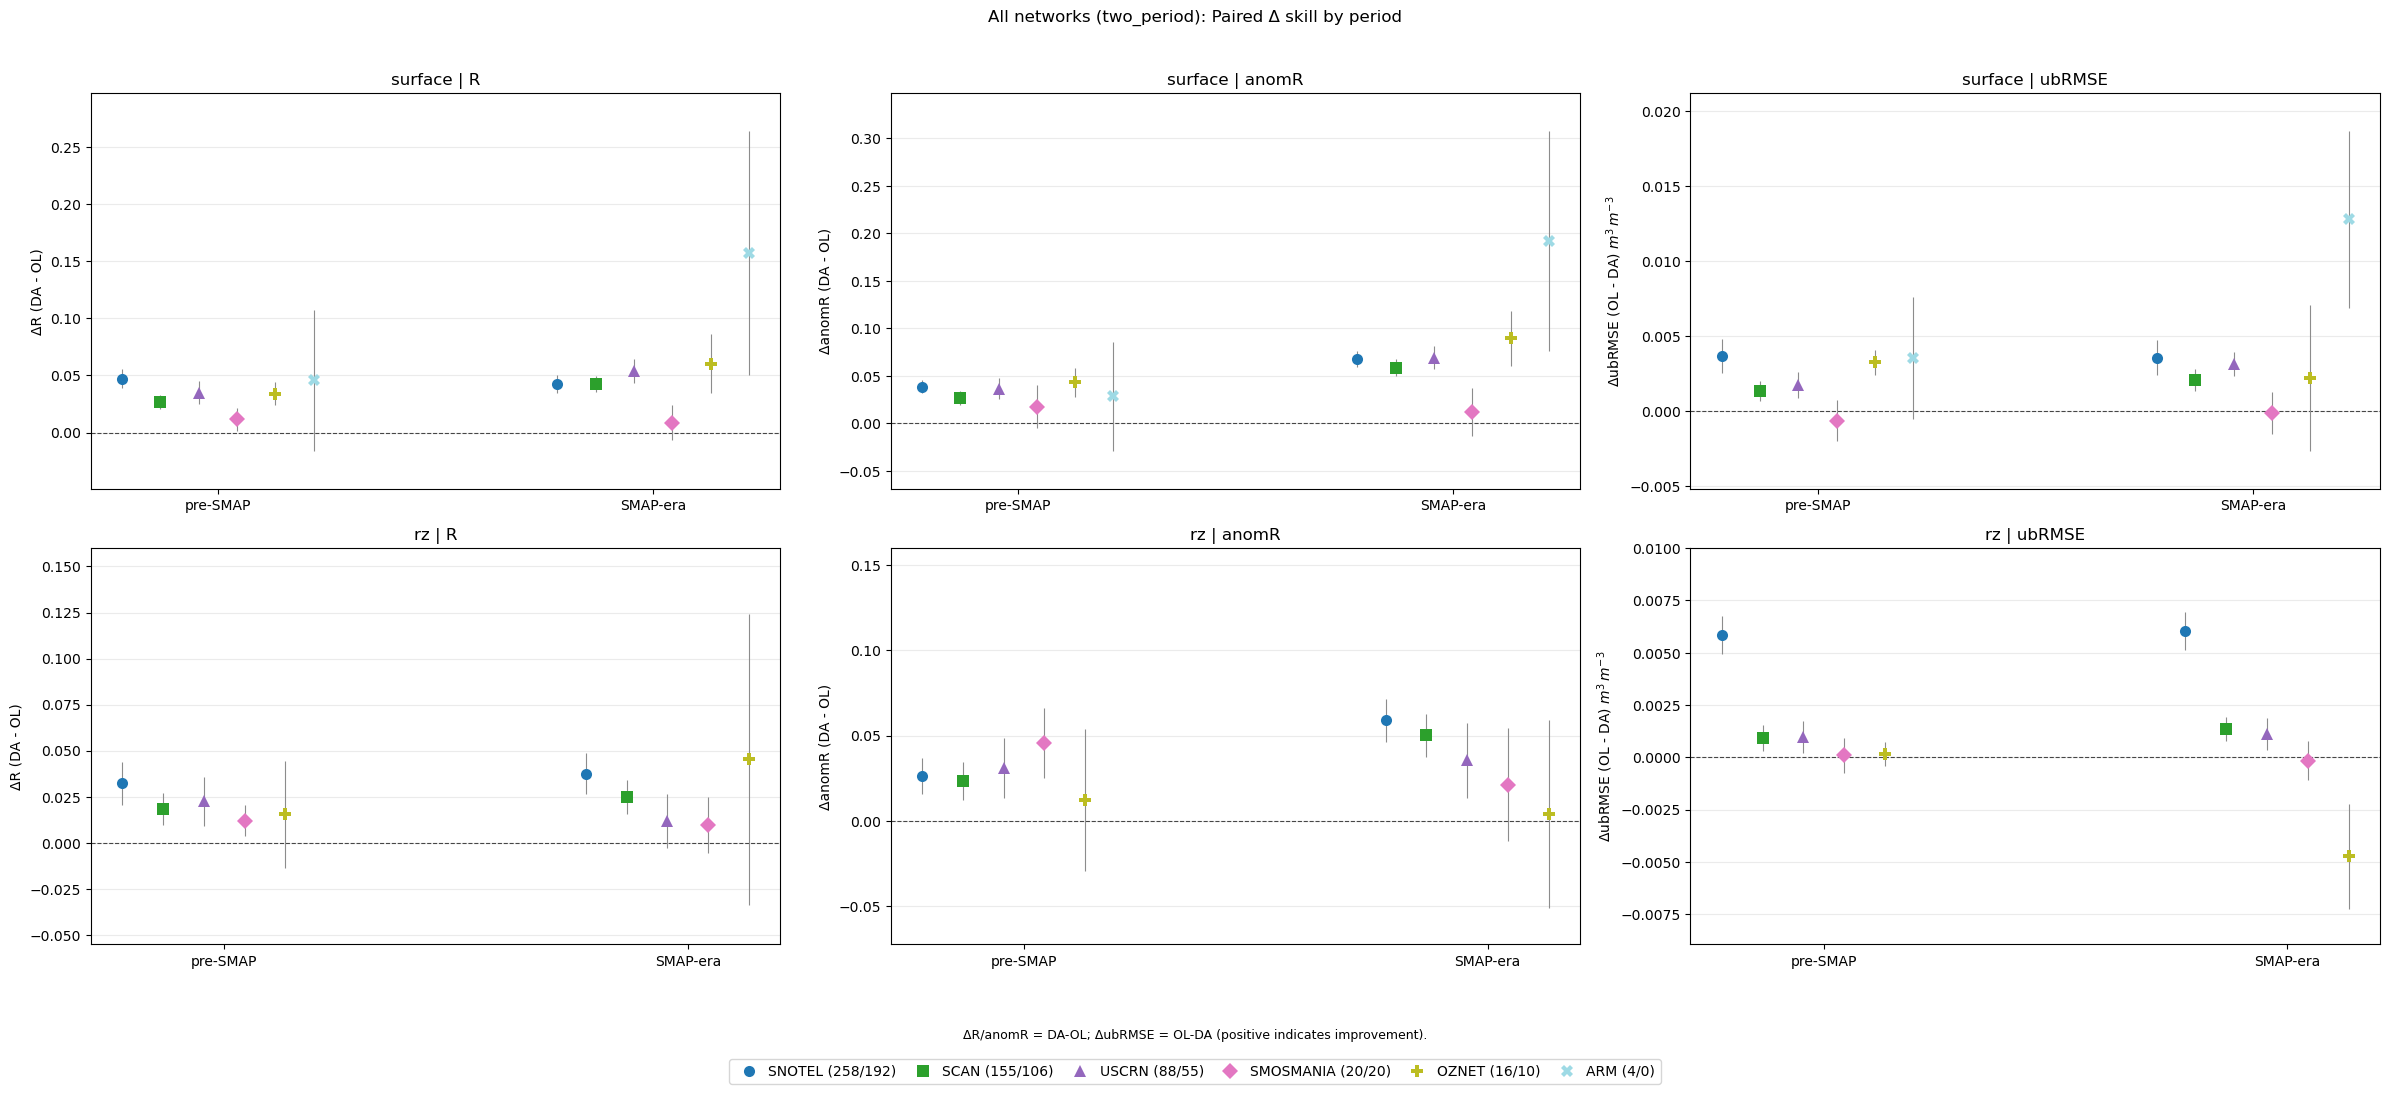

Wrote combined delta figure (two_period): outputs_ismn_network_skill/batch_figures/all_networks_two_period_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_81569/1770589049.py:443: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, n_net))


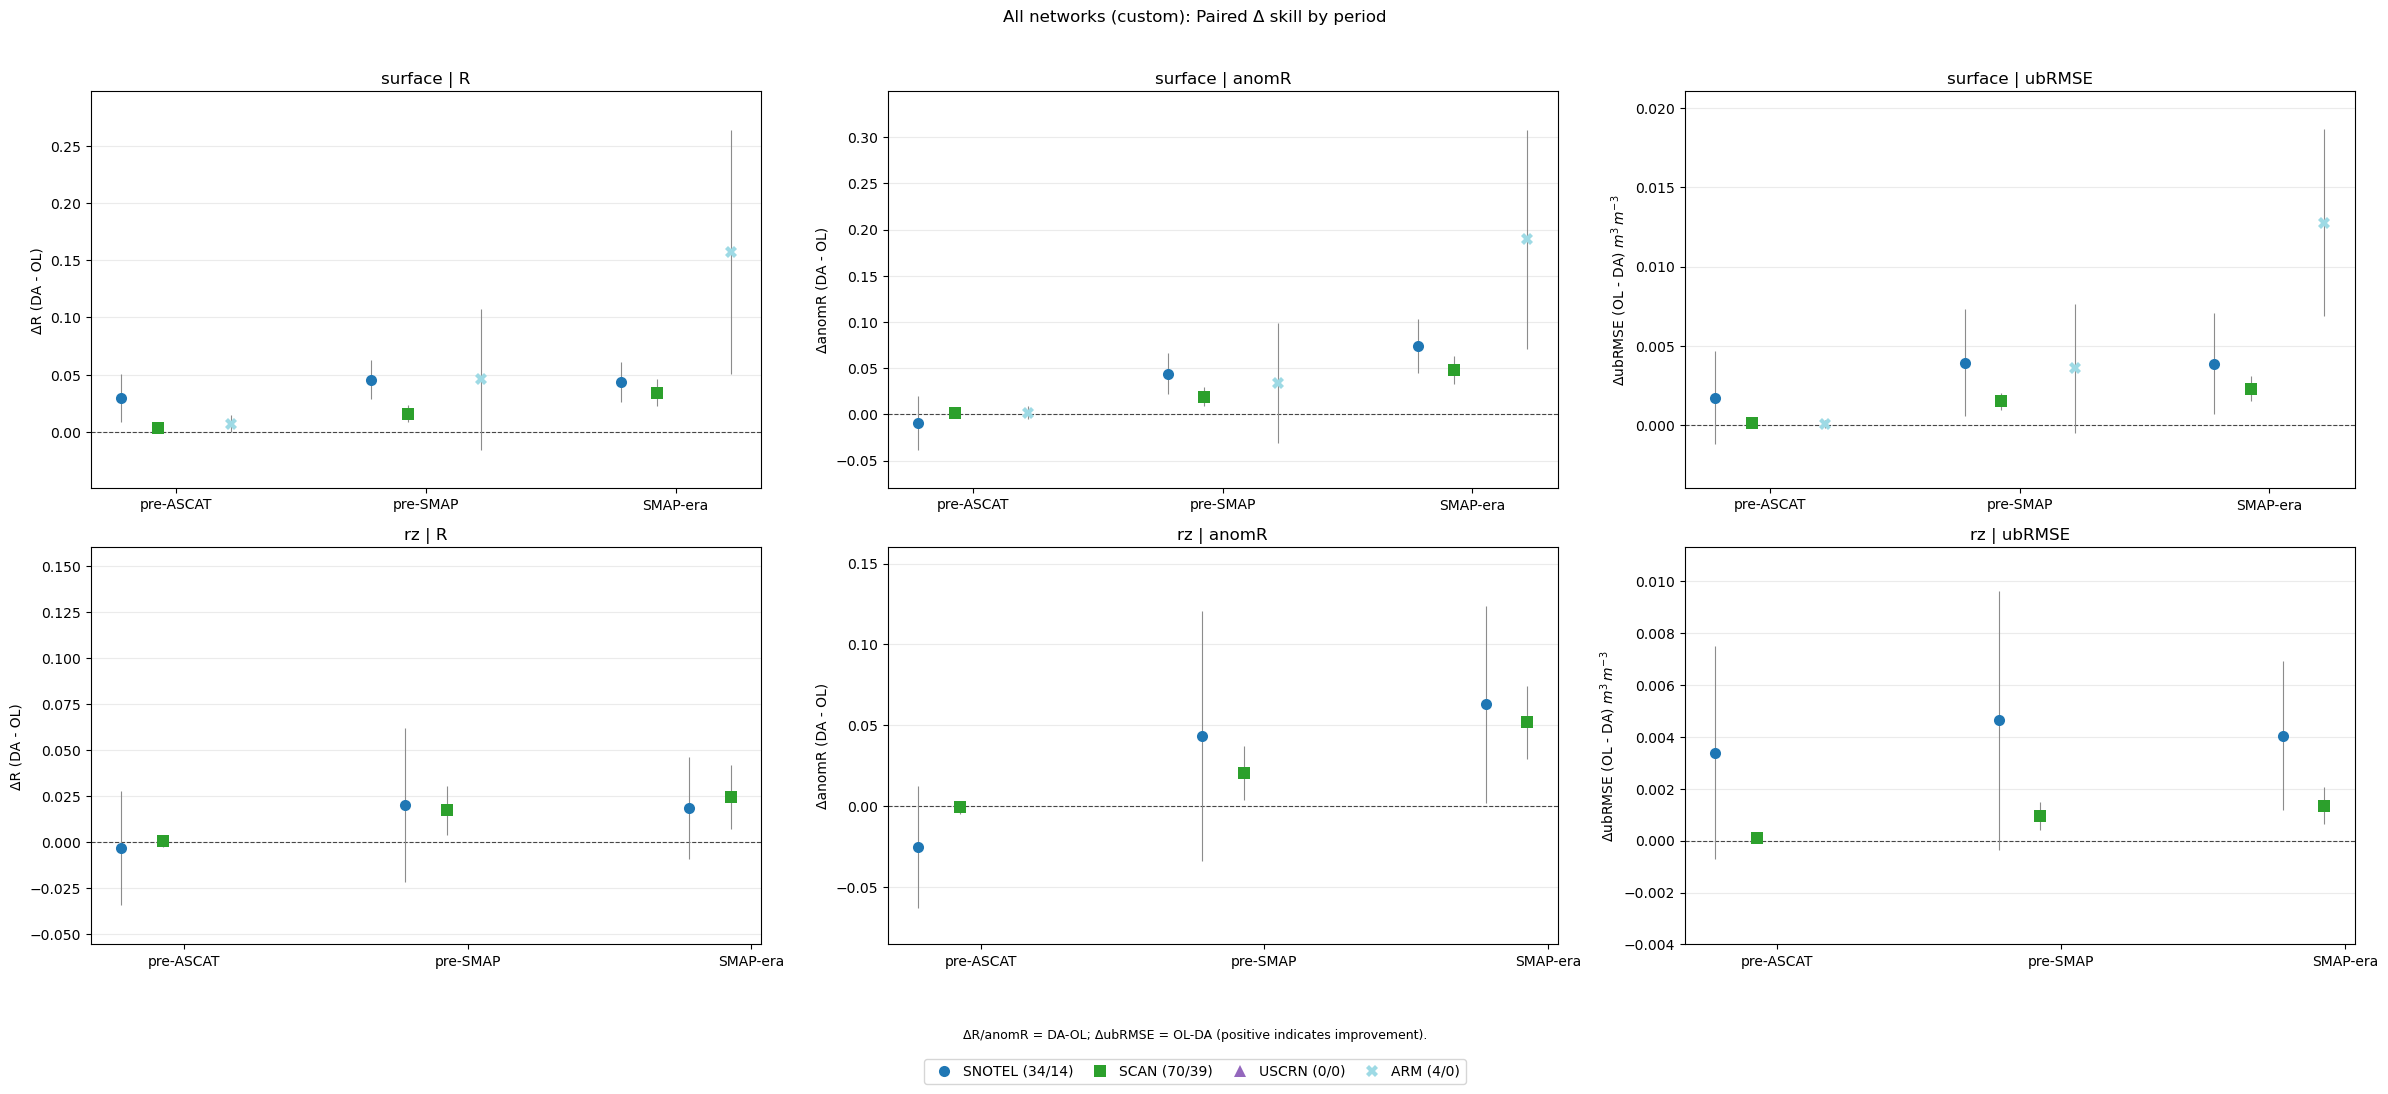

Wrote combined delta figure (custom): outputs_ismn_network_skill/batch_figures/all_networks_custom_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png

Done
Processed: 10
Failed: 0

Per-cache bar-figure results:


,cache_file,network,window_mode,n_exp,n_windows,raw_stats_rows,qc_stats_rows,figure_path,delta_rows
0,ARM_custom_20000601_20240601_matlab_strict_arm...,ARM,custom,2,3,420,24,outputs_ismn_network_skill/batch_figures/ARM_c...,18
1,ARM_two_period_20070601_20240601_matlab_strict...,ARM,two_period,2,2,280,16,outputs_ismn_network_skill/batch_figures/ARM_t...,12
2,OZNET_two_period_20070601_20240601_matlab_stri...,OZNET,two_period,2,2,304,104,outputs_ismn_network_skill/batch_figures/OZNET...,12
3,SCAN_custom_20000601_20240601_matlab_strict_sc...,SCAN,custom,2,3,2664,654,outputs_ismn_network_skill/batch_figures/SCAN_...,18
4,SCAN_two_period_20070601_20240601_matlab_stric...,SCAN,two_period,2,2,1776,1044,outputs_ismn_network_skill/batch_figures/SCAN_...,12
5,SMOSMANIA_two_period_20070601_20240601_matlab_...,SMOSMANIA,two_period,2,2,176,160,outputs_ismn_network_skill/batch_figures/SMOSM...,12
6,SNOTEL_custom_20000601_20240601_matlab_strict_...,SNOTEL,custom,2,3,6096,288,outputs_ismn_network_skill/batch_figures/SNOTE...,18
7,SNOTEL_two_period_20070601_20240601_matlab_str...,SNOTEL,two_period,2,2,4064,1800,outputs_ismn_network_skill/batch_figures/SNOTE...,12
8,USCRN_custom_20000601_20240601_matlab_strict_u...,USCRN,custom,2,3,1380,0,outputs_ismn_network_skill/batch_figures/USCRN...,18
9,USCRN_two_period_20070601_20240601_matlab_stri...,USCRN,two_period,2,2,920,572,outputs_ismn_network_skill/batch_figures/USCRN...,12



Combined delta figures:


,window_mode,n_networks,combined_delta_figure_path
0,two_period,6,outputs_ismn_network_skill/batch_figures/all_n...
1,custom,4,outputs_ismn_network_skill/batch_figures/all_n...


In [7]:
# -------------------------
# Batch run
# -------------------------

all_files = sorted(CACHE_DIR.glob(CACHE_GLOB))
if len(ONLY_FILES) > 0:
    wanted = set([str(x) for x in ONLY_FILES])
    all_files = [p for p in all_files if p.name in wanted]

print(f"Found {len(all_files)} cache files")
for p in all_files:
    print(" -", p.name)

results = []
errors = []
delta_tables = []
summary_tables = []

for i, cache_path in enumerate(all_files, start=1):
    print("=" * 100)
    print(f"[{i}/{len(all_files)}] Processing {cache_path.name}")
    try:
        out = process_one_cache(cache_path)

        delta_df = out.pop("delta_df", pd.DataFrame())
        if isinstance(delta_df, pd.DataFrame) and len(delta_df) > 0:
            delta_tables.append(delta_df)

        summary_df = out.pop("summary_df", pd.DataFrame())
        if isinstance(summary_df, pd.DataFrame) and len(summary_df) > 0:
            summary_tables.append(summary_df)

        results.append(out)
        print(f"Wrote figure: {out['figure_path']}")
        print(f"Rows raw/qc: {out['raw_stats_rows']}/{out['qc_stats_rows']}")
    except Exception as exc:
        errors.append({"cache_file": cache_path.name, "error": str(exc)})
        print(f"ERROR: {cache_path.name}: {exc}")

results_df = pd.DataFrame(results)
errors_df = pd.DataFrame(errors)
summary_all_df = pd.DataFrame()

combined_delta_rows = []
if len(summary_tables) > 0:
    summary_all_df = pd.concat(summary_tables, ignore_index=True)

if len(delta_tables) > 0:
    delta_all_df = pd.concat(delta_tables, ignore_index=True)

    # One global network order/style so symbols are consistent across mode figures.
    rank_df = (
        delta_all_df[(delta_all_df["metric"] == "R") & (delta_all_df["domain"] == "surface")]
        .groupby("network", dropna=True)["n_pairs"]
        .mean()
        .sort_values(ascending=False)
    )
    network_order = [str(x) for x in rank_df.index.tolist()]
    for net in sorted(delta_all_df["network"].dropna().unique().tolist()):
        if net not in network_order:
            network_order.append(net)

    markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h", "8"]
    cmap = plt.cm.get_cmap("tab20", max(1, len(network_order)))
    network_style_map = {
        net: {"marker": markers[i % len(markers)], "color": cmap(i)}
        for i, net in enumerate(network_order)
    }

    for mode in ["two_period", "custom"]:
        sub = delta_all_df[delta_all_df["window_mode"] == mode].copy()
        if len(sub) == 0:
            continue

        fig_path = plot_delta_combined_for_mode(
            sub,
            window_mode=mode,
            exp_control="OL",
            exp_test="DA",
            show_inline=True,
            style_map=network_style_map,
            network_order=network_order,
        )
        print(f"Wrote combined delta figure ({mode}): {fig_path}")
        combined_delta_rows.append(
            {
                "window_mode": mode,
                "n_networks": int(sub["network"].nunique()),
                "combined_delta_figure_path": str(fig_path),
            }
        )
else:
    print("No delta tables available for combined figures.")

combined_delta_df = pd.DataFrame(combined_delta_rows)

print()
print("Done")
print("Processed:", len(results_df))
print("Failed:", len(errors_df))

print()
print("Per-cache bar-figure results:")
display(results_df)

if len(combined_delta_df) > 0:
    print()
    print("Combined delta figures:")
    display(combined_delta_df)

if len(errors_df) > 0:
    print()
    print("Errors:")
    display(errors_df)



## OL/DA stats table used for delta figures (with CI)

Build a per-network table of OL/DA values and confidence intervals for the same metrics/windows/domains used in the delta figures.


In [8]:
import numpy as np
import pandas as pd

if "summary_all_df" not in globals() or len(summary_all_df) == 0:
    raise RuntimeError("summary_all_df is missing/empty. Run the batch cell first.")

# Optional t-based CI factor if scipy is available; fallback to 1.96.
try:
    from scipy.stats import t as _student_t
except Exception:
    _student_t = None

def _ci95_half_from_sem(sem, n):
    if not np.isfinite(sem):
        return np.nan
    if not np.isfinite(n) or int(n) <= 1:
        return np.nan
    if _student_t is None:
        k = 1.96
    else:
        k = float(_student_t.ppf(0.975, df=int(n) - 1))
    return float(k * sem)

tbl = summary_all_df.copy()
for c in ["mean", "sem", "n_sites", "n_sites_common_across_windows", "legacy_ci_lo", "legacy_ci_up"]:
    if c in tbl.columns:
        tbl[c] = pd.to_numeric(tbl[c], errors="coerce")

tbl["ci95_half"] = [
    _ci95_half_from_sem(sem, n)
    for sem, n in zip(tbl["sem"].to_numpy(dtype=float), tbl["n_sites"].to_numpy(dtype=float))
]

id_cols = [
    "network", "window_mode", "window", "domain", "metric",
    "n_sites_common_across_windows", "site_set_rule", "cache_file",
]

wide = (
    tbl[id_cols + ["exp", "mean", "sem", "ci95_half", "n_sites", "legacy_ci_lo", "legacy_ci_up"]]
    .pivot_table(
        index=id_cols,
        columns="exp",
        values=["mean", "sem", "ci95_half", "n_sites", "legacy_ci_lo", "legacy_ci_up"],
        aggfunc="first",
    )
    .reset_index()
)

# Flatten pivot columns: e.g., ("mean", "OL") -> "OL_mean"
flat_cols = []
for c in wide.columns:
    if isinstance(c, tuple):
        top, exp = c
        top = str(top)
        exp = str(exp)
        if exp in ["", "None"]:
            flat_cols.append(top)
        else:
            flat_cols.append(f"{exp}_{top}")
    else:
        flat_cols.append(str(c))
wide.columns = flat_cols

# Merge paired-delta summary (if available) for side-by-side reference.
if "delta_all_df" in globals() and isinstance(delta_all_df, pd.DataFrame) and len(delta_all_df) > 0:
    dsub = delta_all_df[["network", "window_mode", "window", "domain", "metric", "delta_mean", "delta_ci_half", "n_pairs"]].copy()
    out_df = wide.merge(dsub, on=["network", "window_mode", "window", "domain", "metric"], how="left")
else:
    out_df = wide.copy()

# Preferred column order if present
pref_cols = [
    "network", "window_mode", "window", "domain", "metric",
    "OL_mean", "OL_sem", "OL_ci95_half", "OL_legacy_ci_lo", "OL_legacy_ci_up", "OL_n_sites",
    "DA_mean", "DA_sem", "DA_ci95_half", "DA_legacy_ci_lo", "DA_legacy_ci_up", "DA_n_sites",
    "delta_mean", "delta_ci_half", "n_pairs",
    "n_sites_common_across_windows", "site_set_rule", "cache_file",
]
out_cols = [c for c in pref_cols if c in out_df.columns] + [c for c in out_df.columns if c not in pref_cols]
out_df = out_df[out_cols].sort_values(["window_mode", "network", "domain", "metric", "window"]).reset_index(drop=True)

print("OL/DA stats table (means + CI) aligned with delta-figure dimensions:")
display(out_df)

# Optional persisted CSV for slide/table use
ol_da_table_path = OUTPUT_FIG_DIR / "all_networks_ol_da_stats_with_ci_for_delta_figures.csv"
out_df.to_csv(ol_da_table_path, index=False)
print(f"Wrote table: {ol_da_table_path}")




OL/DA stats table (means + CI) aligned with delta-figure dimensions:


,network,window_mode,window,domain,metric,OL_mean,OL_sem,OL_ci95_half,OL_legacy_ci_lo,OL_legacy_ci_up,...,DA_ci95_half,DA_legacy_ci_lo,DA_legacy_ci_up,DA_n_sites,delta_mean,delta_ci_half,n_pairs,n_sites_common_across_windows,site_set_rule,cache_file
0,ARM,custom,SMAP-era,rz,R,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0,0,finite_metric_in_all_windows,ARM_custom_20000601_20240601_matlab_strict_arm...
1,ARM,custom,pre-ASCAT,rz,R,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0,0,finite_metric_in_all_windows,ARM_custom_20000601_20240601_matlab_strict_arm...
2,ARM,custom,pre-SMAP,rz,R,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0,0,finite_metric_in_all_windows,ARM_custom_20000601_20240601_matlab_strict_arm...
3,ARM,custom,SMAP-era,rz,anomR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0,0,finite_metric_in_all_windows,ARM_custom_20000601_20240601_matlab_strict_arm...
4,ARM,custom,pre-ASCAT,rz,anomR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,NaN,NaN,0,0,finite_metric_in_all_windows,ARM_custom_20000601_20240601_matlab_strict_arm...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,USCRN,two_period,pre-SMAP,surface,R,0.674103,0.014216,0.028255,-0.012404,0.009322,...,0.024428,-0.011307,0.008382,88,0.035037,0.010097,88,88,finite_metric_in_all_windows,USCRN_two_period_20070601_20240601_matlab_stri...
140,USCRN,two_period,SMAP-era,surface,anomR,0.568066,0.012449,0.024743,-0.008954,0.007835,...,0.024376,-0.007765,0.006713,88,0.069053,0.012125,88,88,finite_metric_in_all_windows,USCRN_two_period_20070601_20240601_matlab_stri...
141,USCRN,two_period,pre-SMAP,surface,anomR,0.607205,0.013029,0.025897,-0.011116,0.009183,...,0.023236,-0.009875,0.008147,88,0.036282,0.011064,88,88,finite_metric_in_all_windows,USCRN_two_period_20070601_20240601_matlab_stri...
142,USCRN,two_period,SMAP-era,surface,ubRMSE,0.053994,0.001857,0.003691,-0.000582,0.000752,...,0.003426,-0.000551,0.000712,88,0.003162,0.000823,88,88,finite_metric_in_all_windows,USCRN_two_period_20070601_20240601_matlab_stri...


Wrote table: outputs_ismn_network_skill/batch_figures/all_networks_ol_da_stats_with_ci_for_delta_figures.csv


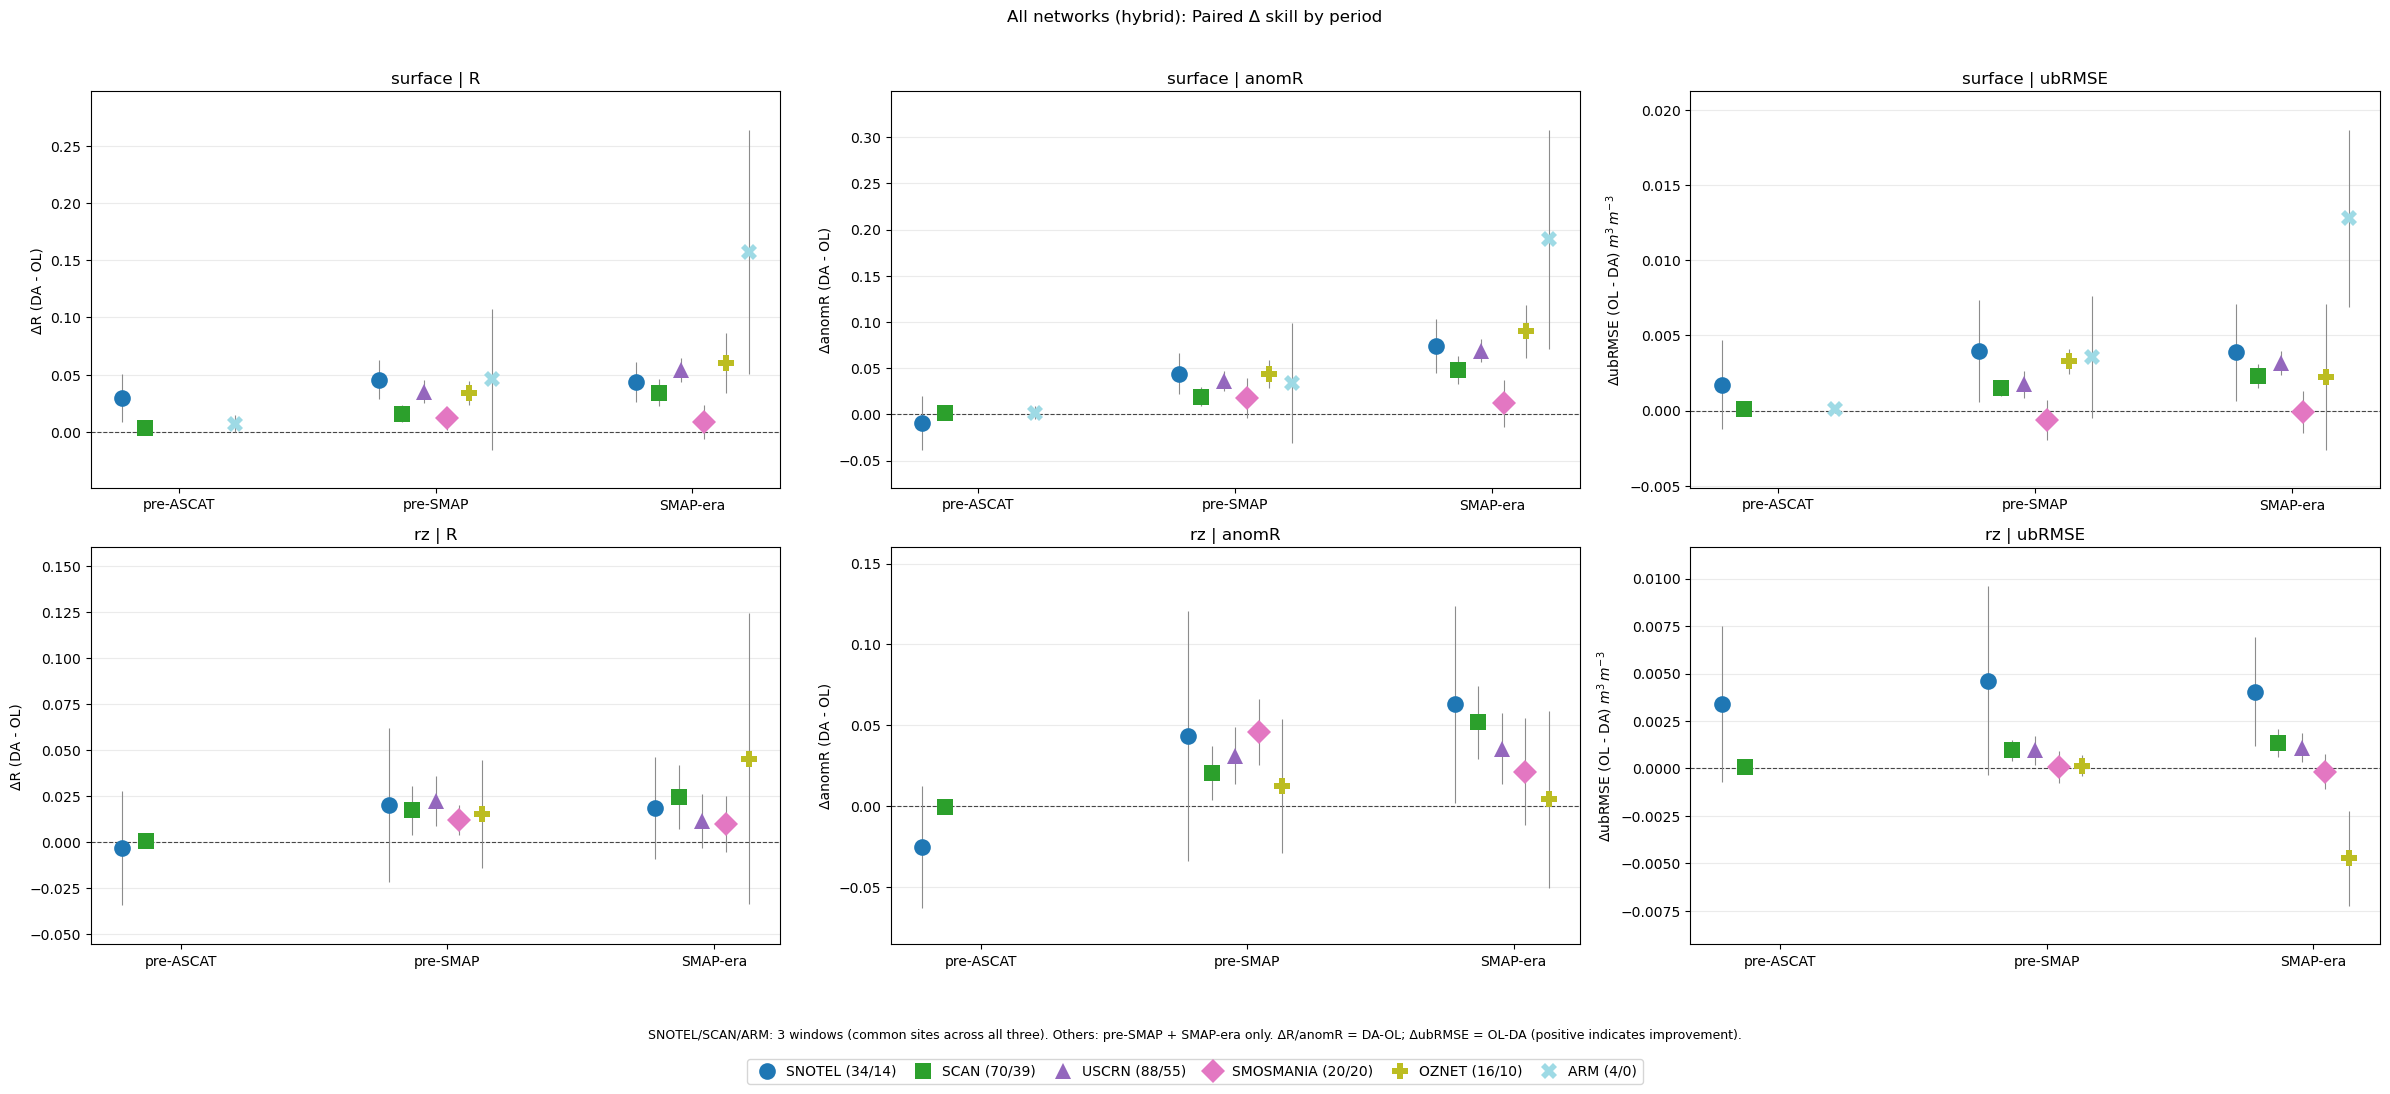

Wrote hybrid combined delta figure: outputs_ismn_network_skill/batch_figures/all_networks_hybrid_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png
Wrote machine-readable plot table: outputs_ismn_network_skill/batch_figures/all_networks_hybrid_OL_DA_delta_surface_rz_R_anomR_ubRMSE_table.csv


,network,domain,metric,window,window_mode,delta_mean,delta_ci_half,n_pairs,delta_def,cache_file,window_position,is_three_window_network,point_is_plotted
0,SNOTEL,surface,R,pre-ASCAT,custom,0.029481,0.020794,34.0,DA-OL,SNOTEL_custom_20000601_20240601_matlab_strict_...,0,True,True
1,SNOTEL,surface,R,pre-SMAP,custom,0.045747,0.017230,34.0,DA-OL,SNOTEL_custom_20000601_20240601_matlab_strict_...,1,True,True
2,SNOTEL,surface,R,SMAP-era,custom,0.043626,0.017673,34.0,DA-OL,SNOTEL_custom_20000601_20240601_matlab_strict_...,2,True,True
3,SNOTEL,surface,anomR,pre-ASCAT,custom,-0.009434,0.029198,34.0,DA-OL,SNOTEL_custom_20000601_20240601_matlab_strict_...,0,True,True
4,SNOTEL,surface,anomR,pre-SMAP,custom,0.044155,0.021702,34.0,DA-OL,SNOTEL_custom_20000601_20240601_matlab_strict_...,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,ARM,rz,anomR,pre-SMAP,custom,NaN,NaN,0.0,DA-OL,ARM_custom_20000601_20240601_matlab_strict_arm...,1,True,False
104,ARM,rz,anomR,SMAP-era,custom,NaN,NaN,0.0,DA-OL,ARM_custom_20000601_20240601_matlab_strict_arm...,2,True,False
105,ARM,rz,ubRMSE,pre-ASCAT,custom,NaN,NaN,0.0,OL-DA,ARM_custom_20000601_20240601_matlab_strict_arm...,0,True,False
106,ARM,rz,ubRMSE,pre-SMAP,custom,NaN,NaN,0.0,OL-DA,ARM_custom_20000601_20240601_matlab_strict_arm...,1,True,False


In [9]:
# Hybrid combined-delta figure:
# - SNOTEL/SCAN/ARM use 3 windows (custom mode: pre-ASCAT, pre-SMAP, SMAP-era)
# - All other networks use 2 windows (two_period mode: pre-SMAP, SMAP-era)

if "delta_all_df" not in globals() or not isinstance(delta_all_df, pd.DataFrame) or len(delta_all_df) == 0:
    raise RuntimeError("delta_all_df is missing/empty. Run the batch cell first.")

special_tokens = {"SNOTEL", "SCAN", "ARM"}
window_order = ["pre-ASCAT", "pre-SMAP", "SMAP-era"]
metric_order = ["R", "anomR", "ubRMSE"]
domain_order = ["surface", "rz"]
marker_size = 12  # ~50% larger than previous size (8)


def _norm_name(s):
    return re.sub(r"[^A-Z0-9]+", "_", str(s).upper())


def _is_three_window_network(network_name):
    n = _norm_name(network_name)
    tag = f"_{n}_"
    return any(f"_{tok}_" in tag for tok in special_tokens)


src = delta_all_df.copy()
src["network"] = src["network"].astype(str)
src["_is_three"] = src["network"].map(_is_three_window_network)

three_df = src[
    src["_is_three"]
    & (src["window_mode"] == "custom")
    & (src["window"].isin(window_order))
].copy()

two_df = src[
    (~src["_is_three"])
    & (src["window_mode"] == "two_period")
    & (src["window"].isin(["pre-SMAP", "SMAP-era"]))
].copy()

hybrid_df = pd.concat([three_df, two_df], ignore_index=True)
if len(hybrid_df) == 0:
    raise RuntimeError("Hybrid subset is empty. Check available cache modes/networks in delta_all_df.")

# Determine network order
networks_present = sorted(hybrid_df["network"].dropna().unique().tolist())
if "network_order" in globals() and isinstance(network_order, list):
    ordered = [n for n in network_order if n in networks_present]
    networks = ordered + [n for n in networks_present if n not in ordered]
else:
    networks = networks_present

# Style map (reuse from batch if available)
if "network_style_map" in globals() and isinstance(network_style_map, dict):
    style_map = network_style_map
else:
    markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h", "8"]
    cmap = plt.cm.get_cmap("tab20", max(1, len(networks)))
    style_map = {
        net: {"marker": markers[i % len(markers)], "color": cmap(i)}
        for i, net in enumerate(networks)
    }

panel_info_delta = {
    "R": (r"ΔR (DA - OL)", (-0.02, 0.16)),
    "anomR": (r"ΔanomR (DA - OL)", (-0.02, 0.16)),
    "ubRMSE": (r"ΔubRMSE (OL - DA) $m^3\,m^{-3}$", (-0.004, 0.010)),
}

x = np.arange(len(window_order), dtype=float)
n_net = len(networks)
offsets = np.array([0.0]) if n_net <= 1 else np.linspace(-0.22, 0.22, n_net)

fig, axs = plt.subplots(2, len(metric_order), figsize=(24, 11), sharex=False)
if len(metric_order) == 1:
    axs = np.array(axs).reshape(2, 1)

legend_handles = []

for i, domain in enumerate(domain_order):
    for j, metric in enumerate(metric_order):
        ax = axs[i, j]

        all_low = []
        all_high = []

        for ni, network in enumerate(networks):
            sub = hybrid_df[
                (hybrid_df["network"] == network)
                & (hybrid_df["domain"] == domain)
                & (hybrid_df["metric"] == metric)
            ].set_index("window").reindex(window_order)

            y = sub["delta_mean"].to_numpy(dtype=float)
            ci = sub["delta_ci_half"].to_numpy(dtype=float)
            xpos = x + offsets[ni]

            st = style_map.get(network, {})
            color = st.get("color", plt.cm.tab20(ni))
            marker = st.get("marker", "o")

            ln = ax.errorbar(
                xpos,
                y,
                yerr=ci,
                fmt=marker,
                linestyle="none",
                color=color,
                ecolor="0.55",
                elinewidth=0.8,
                capsize=2,
                markersize=marker_size,
                markeredgewidth=0.0,
                zorder=3,
            )

            if (i == 0) and (j == 0):
                legend_handles.append(ln.lines[0])

            valid_y = np.isfinite(y)
            if np.any(valid_y):
                ci0 = np.where(np.isfinite(ci), ci, 0.0)
                all_low.extend((y[valid_y] - ci0[valid_y]).tolist())
                all_high.extend((y[valid_y] + ci0[valid_y]).tolist())

        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        ax.set_xticks(x)
        ax.set_xticklabels(window_order)

        ylabel, base_ylim = panel_info_delta[metric]
        y0, y1 = base_ylim
        if len(all_low) > 0 and len(all_high) > 0:
            data_min = float(np.nanmin(all_low))
            data_max = float(np.nanmax(all_high))
            span = max(data_max - data_min, y1 - y0, 1e-6)
            pad = 0.12 * span
            y0 = min(y0, data_min - pad)
            y1 = max(y1, data_max + pad)

        ax.set_ylabel(ylabel)
        ax.set_ylim(y0, y1)
        ax.set_title(f"{domain} | {metric}")


def _network_count_label(network):
    subn = hybrid_df[hybrid_df["network"] == network]

    s = subn[(subn["metric"] == "R") & (subn["domain"] == "surface")].set_index("window").reindex(window_order)["n_pairs"].to_numpy(dtype=float)
    r = subn[(subn["metric"] == "R") & (subn["domain"] == "rz")].set_index("window").reindex(window_order)["n_pairs"].to_numpy(dtype=float)

    # Use the smallest finite paired count across relevant windows to be conservative.
    s_valid = s[np.isfinite(s)]
    r_valid = r[np.isfinite(r)]
    ns = int(np.nanmin(s_valid)) if s_valid.size > 0 else 0
    nr = int(np.nanmin(r_valid)) if r_valid.size > 0 else 0
    return f"{network} ({ns}/{nr})"


legend_labels = [_network_count_label(net) for net in networks]
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=max(1, len(legend_labels)),
    frameon=True,
    bbox_to_anchor=(0.5, 0.012),
    fontsize=10,
    handletextpad=0.4,
    columnspacing=0.9,
)

fig.suptitle(
    "All networks (hybrid): Paired Δ skill by period",
    y=0.995,
)
fig.text(
    0.50,
    0.06,
    "SNOTEL/SCAN/ARM: 3 windows (common sites across all three). Others: pre-SMAP + SMAP-era only. "
    "ΔR/anomR = DA-OL; ΔubRMSE = OL-DA (positive indicates improvement).",
    ha="center",
    fontsize=9,
)

plt.tight_layout(rect=(0.0, 0.11, 1.0, 0.98))

hybrid_fig_path = OUTPUT_FIG_DIR / "all_networks_hybrid_OL_DA_delta_surface_rz_R_anomR_ubRMSE.png"
fig.savefig(hybrid_fig_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Wrote hybrid combined delta figure: {hybrid_fig_path}")

# Machine-readable plot summary table (one row per plotted network/domain/metric/window)
plot_cols = [
    "network", "window_mode", "window", "domain", "metric",
    "delta_mean", "delta_ci_half", "n_pairs", "delta_def", "cache_file",
]
plot_rows = hybrid_df[plot_cols].copy()

# Resolve possible duplicates deterministically if multiple cache rows exist
plot_rows = (
    plot_rows
    .sort_values(["network", "domain", "metric", "window", "cache_file"])
    .drop_duplicates(subset=["network", "domain", "metric", "window"], keep="last")
)

full_index = pd.MultiIndex.from_product(
    [networks, domain_order, metric_order, window_order],
    names=["network", "domain", "metric", "window"],
)

hybrid_plot_table_df = (
    plot_rows
    .set_index(["network", "domain", "metric", "window"])
    .reindex(full_index)
    .reset_index()
)

hybrid_plot_table_df["window_position"] = hybrid_plot_table_df["window"].map({w: i for i, w in enumerate(window_order)})
hybrid_plot_table_df["is_three_window_network"] = hybrid_plot_table_df["network"].map(_is_three_window_network)
hybrid_plot_table_df["point_is_plotted"] = np.isfinite(hybrid_plot_table_df["delta_mean"])

hybrid_table_path = OUTPUT_FIG_DIR / "all_networks_hybrid_OL_DA_delta_surface_rz_R_anomR_ubRMSE_table.csv"
hybrid_plot_table_df.to_csv(hybrid_table_path, index=False)
print(f"Wrote machine-readable plot table: {hybrid_table_path}")

display(hybrid_plot_table_df)